## Initialization

In [1]:
import cupy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import collision_cp
importlib.reload(collision_cp)
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [2]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 31 / e_mass      # now in a.u.
c6 = 5.2e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0 * 1e6)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 56509.54307916515
C6 520000.0
beta (a0) 492.36682576656693
E_beta (K) 11.525197727053389
tau_beta (s) 4.164130464303455e-06


In [3]:
num_samples = 5000

# properties of resonant spectrum
rrkm = 6e-6     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos
print(mean_spacing)

# thermal properties
temp = 0.2         # in terms of E6
num_resonances = 400        # should be odd
print(1 / (mean_spacing / 2 / np.pi))

0.6940217440505757
9.053297481010492


In [4]:
L = (temp / E_beta / c6) ** (1/6)
print(L) # distance (in a.u.) when energy of potential is equal to temperature
print(L / beta)

4.682301069385612
0.009509781781288225


In [5]:
length = 2 # cutoff distance (in beta)

mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)
# find positive time delay

def get_spectrum():
    while True:
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
        min_positive = np.min(energy_GOE_mat[energy_GOE_mat > 0])
        max_negative = np.max(energy_GOE_mat[energy_GOE_mat < 0])

        f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
        time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
        
        if time_delay > rrkm or True:
            break
    return energy_GOE_mat, W_mat, x_actual, time_delay

energy_GOE_mat, W_mat, x_actual, time_delay = get_spectrum()
print(time_delay)

10.441270435058367


In [56]:
hbar = 1
std_k = 0.1
std_x = 1 / std_k
x0 = 100
k0 = 0.1
print(200 / (2 * k0))

def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase

def wave(t, k, x):
    position = np.exp(1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

def reflected_wave(t, k, x, r):
    position = np.exp(-1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return r(k) * gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)


1000.0


12.068645103263659
(999,)


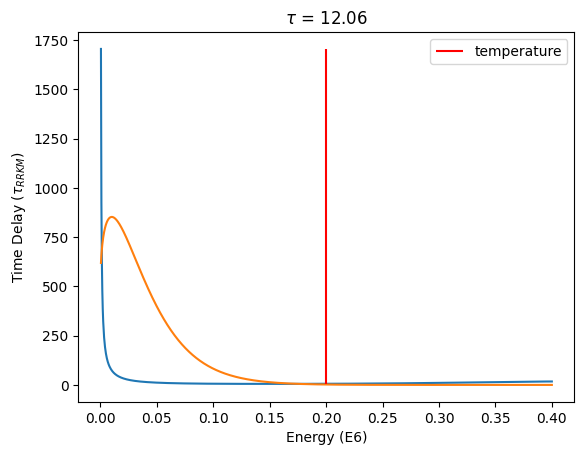

In [57]:
# energy_GOE_mat, W_mat, x_actual, time_delay = get_spectrum()
# while time_delay < 1 / (mean_spacing / 2 / np.pi):
#     energy_GOE_mat, W_mat, x_actual, time_delay = get_spectrum()
print(time_delay)

energy_grid = np.linspace(0, 2 * temp, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(time_delays.shape)
# time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid.get(), time_delays.get())
plt.plot(energy_grid.get(), max(time_delays.get() / np.abs(gaussian_envelope(k0)).get() ** 2 / 2) * np.abs(gaussian_envelope(np.sqrt(energy_grid))).get() ** 2)
plt.vlines(temp, min(time_delays.get()), max(time_delays.get()), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_{RRKM}$)")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
plt.savefig("RbCs/wavepacket/spread.pdf")
plt.show()

In [67]:
exact = 12 * std_k / 3000
print(exact)

0.0004000000000000001


0.00040000000000001146


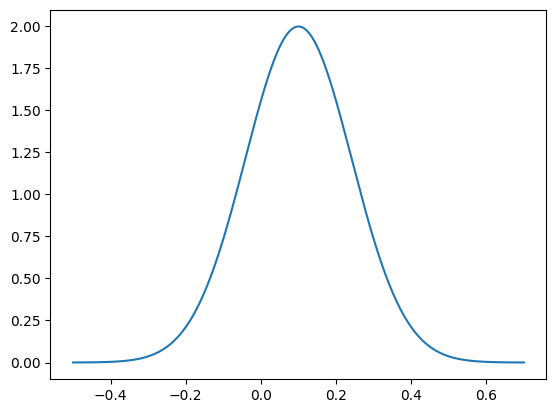

In [71]:
momenta = np.round(np.linspace(k0 - 6 * std_k, k0 + 6 * std_k, 3001), 15)
print(momenta[1] - momenta[0])
plt.plot(momenta.get(), np.abs(gaussian_envelope(momenta)).get())

In [81]:
normalization = np.sum(np.abs(gaussian_envelope(momenta)))
wigner = wigner_smith_matrix(momenta ** 2, energy_GOE_mat, np.square(W_mat))
wigner[np.isnan(wigner)] = 0
wigner[np.abs(momenta) < 0.005] = 0
delay = np.sum(np.abs(gaussian_envelope(momenta)) * wigner) / normalization
print(delay)

416.78958184843106


In [72]:
print(momenta[np.abs(momenta) < 0.001])
smallest = momenta[np.abs(momenta) < 0.0001]
np.max(wigner_smith_matrix(momenta ** 2, energy_GOE_mat, np.square(W_mat)))
print(S_matrix(smallest ** 2, energy_GOE_mat, np.square(W_mat)))

[-0.0008 -0.0004 -0.      0.0004  0.0008]
[1.+0.j]


In [85]:
import pickle

with open("NaK/wavepacket/spectrum.pkl", "wb") as f:
    pickle.dump((energy_GOE_mat, W_mat, x_actual, time_delay), f)

In [7]:
import pickle

with open("NaK/wavepacket/spectrum.pkl", "rb") as f:
    energy_GOE_mat, W_mat, x_actual, time_delay = pickle.load(f)

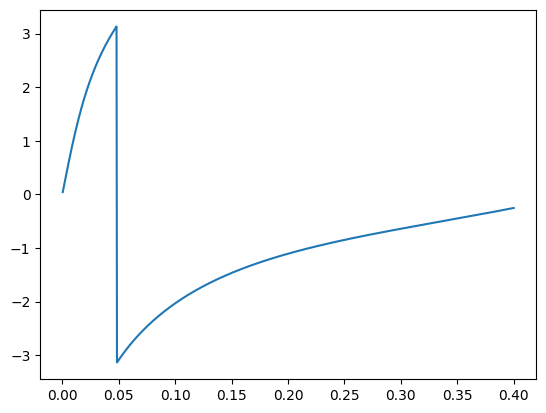

In [87]:
plt.plot(energy_grid.get(), np.angle(S_matrix((energy_grid ** 2), energy_GOE_mat, np.square(W_mat))).get())

0.9481465528382037
Not All of Wave
0.9406358538487204
Delay 170.82790223067377


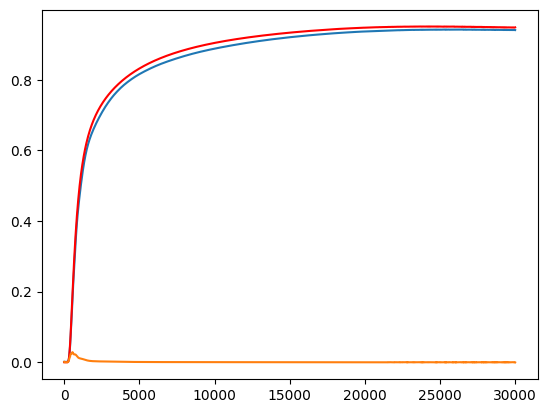

In [74]:
import pickle 

data = {}

for momentum in np.arange(0.1, 0.4, 0.5):
    k0 = momentum.item()

    xs = np.linspace(-800, 200, 1000)
    dx = xs[1] - xs[0]
    index = (xs > 100).argmax().item()

    ps = np.round(np.linspace(k0 - 6 * std_k, k0 + 6 * std_k, 3001), 15)
    dp = ps[1] - ps[0]
    ps = ps.reshape((len(ps), 1))

    maxt = (200 / k0 / 2) * 30
    ts = np.linspace(0, maxt, 1000)
    dt = ts[1] - ts[0]
    time_min = 0
    # print(time_min)

    r1 = lambda k : np.exp(-1j * 2 * k * length) #* S_matrix(k ** 2, energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1))
    psi1 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r1), axis=0)) * dp for t in ts])
    reflected1 = np.array([(np.sum(reflected_wave(t, ps, xs, r1), axis=0)) * dp for t in ts])

    flux_nores = []
    for time_index in range(time_min, len(ts)):
        # offset = (xs > xs[0] + 2 * k0 * ts[time_index]).argmax().item()
        flux_nores.append(1 - np.sum(np.abs(reflected1[time_index][:index]) ** 2 * dx).get())
    flux_nores = np.array(flux_nores)

    pdf_nores = flux_nores.copy()
    for i in range(len(pdf_nores) - 1, 0, -1):
        pdf_nores[i] -= pdf_nores[i - 1]
    print(flux_nores[-1])
    expected_value_nores = np.sum(pdf_nores * ts[time_min:]).item()

    expected_delay = []
    total_percentage = []

    for i in range(1):
        # energy_GOE_mat, W_mat, x_actual, time_delay = get_spectrum()

        r2 = lambda k : np.exp(-1j * 2 * k * length) * np.conj(S_matrix((k ** 2), energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1)))
        psi2 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r2), axis=0)) * dp for t in ts])
        reflected2 = np.array([(np.sum(reflected_wave(t, ps, xs, r2), axis=0)) * dp for t in ts])
        if np.sum(np.abs(reflected2[len(ts) - 1][:index]) ** 2 * dx).get() > 0.05:
            print("Not All of Wave")

        # show_time = 0
        # plt.plot(xs.get(), np.abs(reflected2[show_time]).get() ** 2)
        # plt.show()
        # print(np.sum(np.abs(reflected2[show_time]) ** 2 * dx))

        
        flux = []

        for time_index in range(time_min, len(ts)):
            # offset = (xs > xs[0] + 2 * k0 * ts[time_index]).argmax().item()
            flux.append(1 - np.sum(np.abs(reflected2[time_index][:index]) ** 2 * dx).get())

        flux = np.array(flux)
        total_percentage.append(flux[-1].item())

        pdf = flux.copy()
        for i in range(len(pdf) - 1, 0, -1):
            pdf[i] -= pdf[i - 1]
        print(flux[-1])
        expected_value = np.sum(pdf * ts[time_min:]).item()
        expected_delay.append(expected_value) 

        print("Delay", expected_value - expected_value_nores)

        plt.plot(ts[time_min:].get(), flux.get())
        plt.plot(ts[time_min:].get(), flux_nores.get(), color="red")
        plt.plot(ts[time_min:].get(), pdf.get())
        plt.show()
        break

    save_dict = {"expected value": expected_delay, "percentage": total_percentage}
    data[k0] = save_dict
    # break
    
    # with open("RbCs/wavepacket/sweeep_threshold_nores.pkl", "wb") as f:
    #     pickle.dump(data, f)

# print(data)

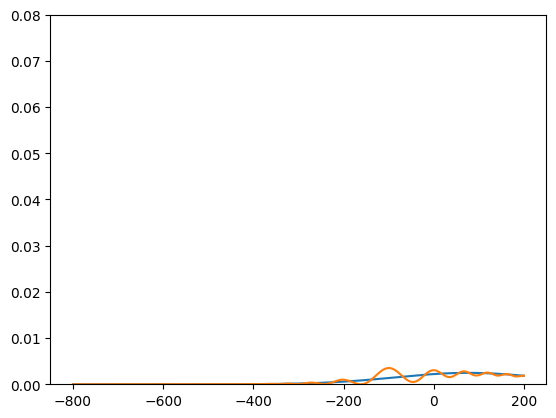

0.792262364462467


In [73]:
show_time = 30
plt.plot(xs.get(), np.abs(reflected1[show_time]).get() ** 2)
plt.plot(xs.get(), np.abs(reflected2[show_time]).get() ** 2)
plt.ylim([0, 0.08])
plt.show()
print(np.sum(np.abs(reflected2[show_time]) ** 2 * dx))

In [17]:
save_dict

{'expected value': [319.80353141822815], 'percentage': [0.999951053749579]}

In [30]:
import pickle 
with open("RbCs/wavepacket/sweeep_threshold.pkl", "rb") as f:
    data = pickle.load(f)
with open("RbCs/wavepacket/sweeep_threshold_nores.pkl", "rb") as f:
    data_nores = pickle.load(f)
print(data)

{0.2: {'expected value': [830.9041483896212, 733.2112169543655, 773.2394013175797, 729.4325318101833, 806.0469888434708, 792.3045535871418, 811.7608557124446, 868.7132853829419, 763.8347307483451, 796.7781188080587, 826.4680098745171, 839.4234222830024, 739.1139789880924, 847.7644328799817, 802.7729571891813, 802.7220321838503, 746.3087316450286, 774.2699362543441, 766.328452050961, 825.8071241251201, 797.8149465136776, 740.1327088989048, 795.4106716474489, 802.8549879886378, 744.7672761157055, 873.3571979195908, 747.1242059611916, 822.2058666353128, 849.6211851051256, 778.8744109803682, 842.5914840686735, 803.8246315841195, 735.0807819297718, 779.7225318924791, 744.4407970741628, 809.6716326722174, 786.415033959844, 766.1959114965013, 786.5264108507412, 844.297223571539, 810.3941300915739, 797.7133682296698, 831.1843092762825, 728.5550841963055, 753.8710716877447, 826.8642290873943, 742.8349310478429, 749.8658090119026, 779.4165808889013, 830.53456556087, 838.3670461292791, 785.160447

0.9905338461311347
Expected 733.1811502181051
Lag 794.5203509837904
Delay 61.33920076568529


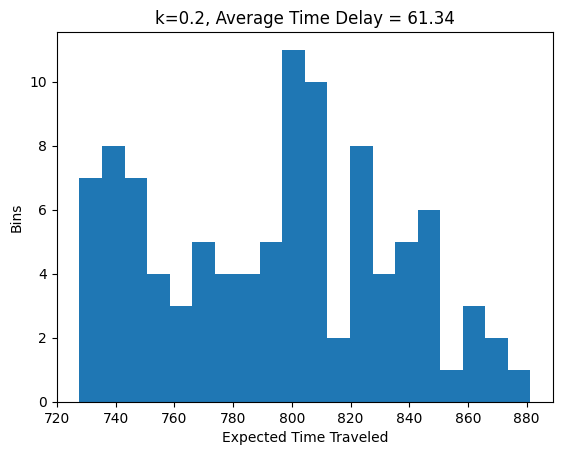

0.9972031782067301
Expected 504.1033944314237
Lag 568.3684727043111
Delay 64.26507827288742


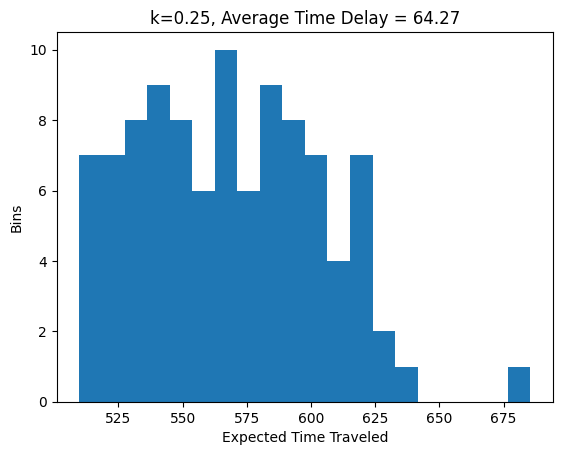

0.999047052240801
Expected 388.34739420834666
Lag 452.8085234050548
Delay 64.46112919670816


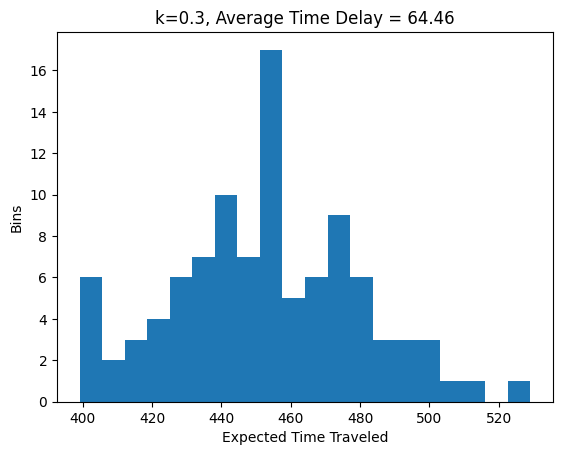

0.9992491915422301
Expected 319.80353141822815
Lag 382.5302382218368
Delay 62.726706803608636


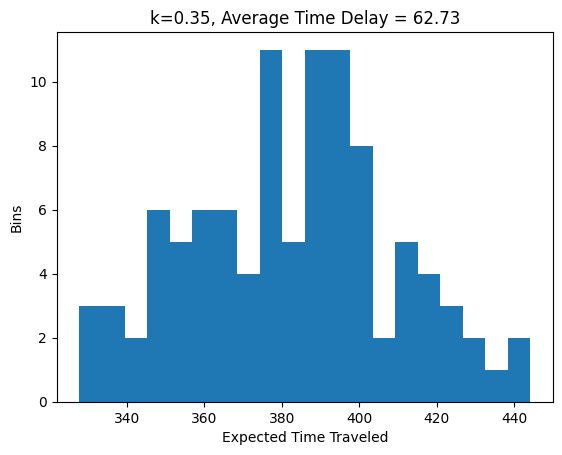

In [35]:
for key in data:
    expected_delay = np.array(data[key]["expected value"])
    total_percentage = data[key]["percentage"]
    print(min(total_percentage))

    speed = key
    lag = np.mean(np.array(data_nores[key]["expected value"]))
    print("Expected", lag)
    print("Lag", np.mean(expected_delay))
    print("Delay", np.mean(expected_delay) - lag)
    plt.hist(expected_delay.get(), bins=20)
    plt.xlabel("Expected Time Traveled")
    plt.ylabel("Bins")
    plt.title(f"k={round(key, 2)}, Average Time Delay = {round((np.mean(expected_delay) - lag).item(), 2)}")
    plt.savefig(f"RbCs/wavepacket/hist_{round(key, 2)}.pdf")
    plt.show()

Half Life 150.30325271059215
Expected 169.71971266818997
RRKM 93.36281412688626


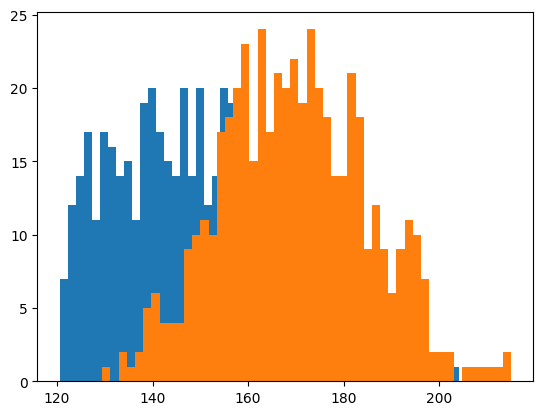

In [17]:
half_life = np.array(data["half life"])
expected_delay = np.array(data["expected value"])
total_percentage = data["percentage"]

print("Half Life", np.mean(half_life))
plt.hist(half_life.get(), bins=50)

print("Expected", np.mean(expected_delay))
plt.hist(expected_delay.get(), bins=50)

print("RRKM", rrkm)

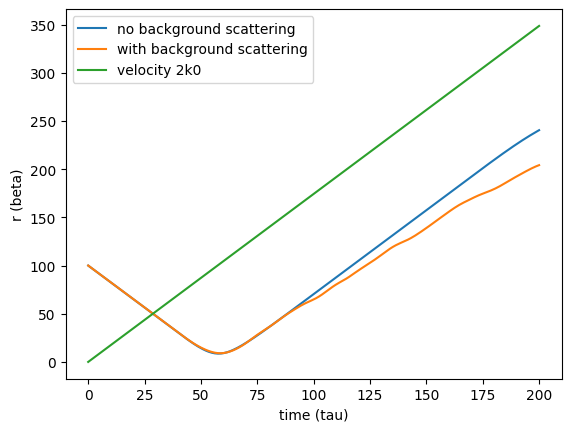

AssertionError: 

In [11]:
from scipy.interpolate import UnivariateSpline

tsnp = ts.get()

plt.plot(tsnp, mean1_g0.get(), label='no background scattering')
plt.plot(tsnp, mean2_g0.get(), label='with background scattering')
plt.plot(tsnp, 2 * tsnp * k0.get(), label='velocity 2k0')
plt.xlabel('time (tau)')
plt.ylabel('r (beta)')
plt.legend()


plt.savefig('./wavepackets/background.pdf')
plt.show()

points = np.arange(11, 120, 1).get()
delays = []
start = 100
for point in points:
    spl1 = UnivariateSpline(tsnp[start:], (mean1_g0[start:] - point).get(), s=0)
    spl2 = UnivariateSpline(tsnp[start:], (mean2_g0[start:] - point).get(), s=0)
    assert(len(spl1.roots()) == 1)
    assert(len(spl2.roots()) == 1)
    r1 = spl1.roots()[0]
    r2 = spl2.roots()[0]
    delays.append(r2 - r1)


plt.plot(points, delays)
plt.show()
print(max(delays))

In [ ]:
(np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2
print(abar / k0)

0.628932628271217


## Together

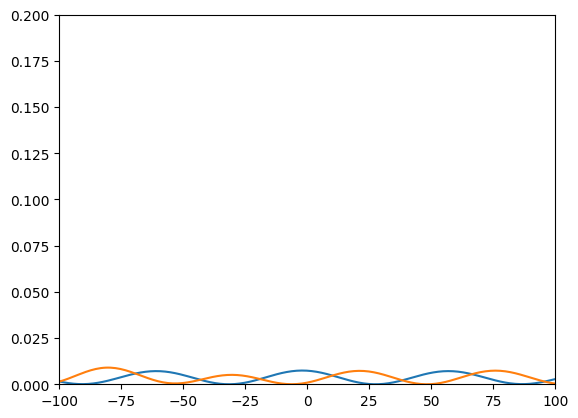

In [78]:
psis = [psi1, psi2]

import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
lines = []
for psi in psis:
    line = ax.plot(xs.get(), np.abs(psi[i]).get() ** 2)[0]
    lines.append(line)
ax.set(xlim=[-100, 100], ylim=[0, 0.2])

num = 1000
# line2 = ax.plot([mean1[0] for i in range(num)], [i / num for i in range(num)], color='red')[0]
# line3 = ax.plot([mean1_g0[0] for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 1
    for j in range(len(psis)):
        lines[j].set_ydata(np.abs(psis[j][i]).get() ** 2)
    # line2.set_xdata([mean1[i] for j in range(num)])
    # line3.set_xdata([mean1_g0[i] for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=30, interval=30)
ani

## Animation 2

NameError: name 'mean2' is not defined

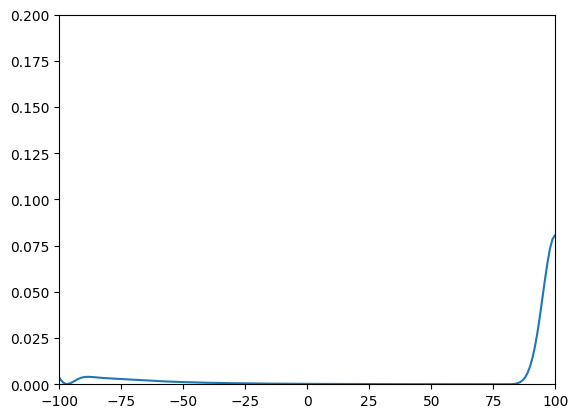

In [77]:
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
line = ax.plot(xs.get(), np.abs(psi2[i]).get() ** 2)[0]
ax.set(xlim=[-100, 100], ylim=[0, 0.2])

num = 1000
line2 = ax.plot([mean2[0].get() for i in range(num)], [i / num for i in range(num)], color='red')[0]
line3 = ax.plot([mean2_g0[0].get() for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 10
    line.set_ydata(np.abs(psi2[i]).get() ** 2)
    line2.set_xdata([mean2[i].get() for j in range(num)])
    line3.set_xdata([mean2_g0[i].get() for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=25, interval=30)
ani

## Animation 1

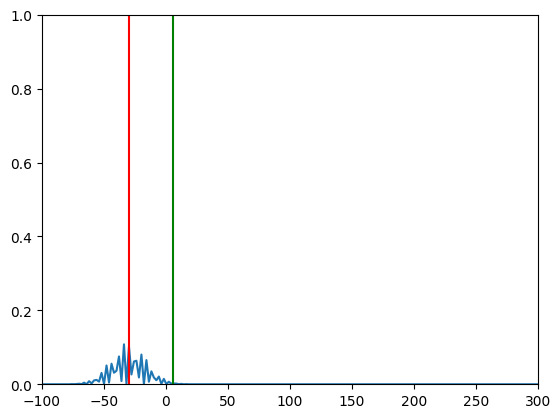

In [274]:
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
line = ax.plot(xs.get(), np.abs(psi1[i]).get() ** 2)[0]
ax.set(xlim=[-100, 300], ylim=[0, 1])

num = 1000
line2 = ax.plot([mean1[0].get() for i in range(num)], [i / num for i in range(num)], color='red')[0]
line3 = ax.plot([mean1_g0[0].get() for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 10
    line.set_ydata(np.abs(psi1[i]).get() ** 2)
    line2.set_xdata([mean1[i].get() for j in range(num)])
    line3.set_xdata([mean1_g0[i].get() for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=20, interval=30)
ani